# Estimarea Pretului pentru Procesoare

In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import Markdown

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

Pentru [df_bench](../data/CPU_benchmark_v4.csv) datele au fost descarcate din: [CPU Benchmarks Compilation](https://www.kaggle.com/datasets/alanjo/cpu-benchmarks)

In [293]:
df = pd.read_csv(r"..\data\CPU_benchmark_v4.csv")

# df.head(20)
# df.isna().sum()
# df.shape
# df.dtypes
# df.describe()

# df["TDP"].value_counts().head(10).plot(kind="barh")
# df["price"].plot(kind="hist", bins=100)

# df["price"].plot(kind="kde") 
# sns.pairplot(df, vars=[""])

# df.plot(kind="scatter", x="TDP", y="price", alpha=0.7)

# Curatarea datelor
Setul de date descarcat din [CPU Benchmarks Compilation](https://www.kaggle.com/datasets/alanjo/cpu-benchmarks) are nevoie de urmatoarele curatari:
-   campul `price` este evaluat in dolari, asa ca trebuie sa convertim din USD in RON.
-   din cauza ca producatorul se afla in numele procesorului, se va creia un camp nou numit `manufacturer` in care va fi separat.
-   incat campurile derivate nu ne intereseaza din setul de date (de ex. campul `cpuValue` este format din `cpuMark / price`) acestea vor fi scoase.
-   campurile care nu contin date in `price` vor fi folosite ca date pentru testarea predictiei, lafel cu procesoarele din fisierul [CPU_r23_v2.csv](../data/CPU_r23_v2.csv)


In [294]:
RATA_RON_USD = 4.39

df['manufacturer'] = df['cpuName'].apply(lambda x: str(x).split()[0] if pd.notnull(x) else 'Unknown')
df['price'] = df['price'] * RATA_RON_USD
df['log_price'] = np.log1p(df['price'])
df = df[[
    'manufacturer',
    'log_price',
    # 'cpuName', 
    'price', 
    'cpuMark', 
    # 'cpuValue', 
    'threadMark', 
    # 'threadValue',
    'TDP', 
    # 'powerPerf', 
    'cores', 
    # 'testDate', 
    # 'socket', 
    'category',
    # 'match_name'
    ]].copy()

# mai pot sa adaug si generatile din unme cum ar fi ryzen 7 i3 etc...

# Analiza exploratorie
Din cauza ca diferenta intre media preturilor si mediana acestora este mare (706.79 vs. 1938) sugereaza ca datele sunt distribuite asimetric spre stanga. Din acest motiv in model se va aplica log() pe pret pentru al aduce mai aproape de o curba gaussiana.

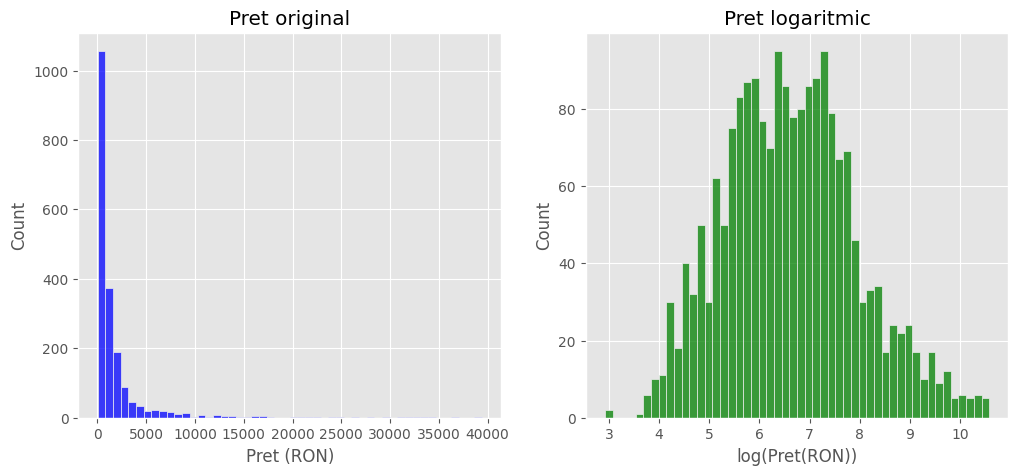

In [295]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['price'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Pret original')
axes[0].set_xlabel('Pret (RON)')

sns.histplot(df['log_price'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Pret logaritmic')
axes[1].set_xlabel('log(Pret(RON))')

plt.show() # diferenta intre graficul original si cel logaritmic

### Correlatie
Pentru a putea afla care factori influenteaza cel mai tare pretul, se va observa urmatorul heatmap.
Din acest heatmap putem extrage urmatoarele rezultate:
-   Pretul este cel mai tare corelat cu scorul de performanta din benchmark, care este un rezultat asteptat.
-   Numarul de nuclee are o corelatie puternica cu pretul, mai puternica ca `threadMark` (performanta pe un singur nucleu).
-   Intre TPD si threadMark corelatia este destul de mica, asa ca mai multa putere nu inseamna cresterea performantei pe un singur nucleu.

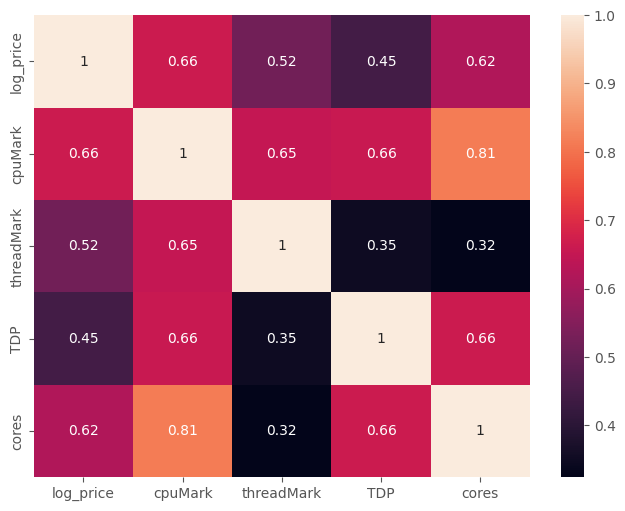

            log_price   cpuMark  threadMark       TDP     cores
log_price    1.000000  0.664349    0.520090  0.445253  0.618283
cpuMark      0.664349  1.000000    0.651022  0.657544  0.814717
threadMark   0.520090  0.651022    1.000000  0.349236  0.323995
TDP          0.445253  0.657544    0.349236  1.000000  0.664270
cores        0.618283  0.814717    0.323995  0.664270  1.000000


In [296]:
plt.figure(figsize=(8, 6))
df_log_price = df.drop('price', axis=1) # pentru ca folosim pretul logaritmic, scoatem pretul original
sns.heatmap(data=df_log_price.corr(numeric_only=True), annot=True)
plt.show()

print(df_log_price.corr(numeric_only=True))


# Feature Engineering
Se vor realiza urmatori pasi:
1. Crea **caracteristici noi** derivate din datele existente
2. Calcula și analiza **corelațiile** între caracteristici (Pearson și Spearman)
3. Evalua **importanța caracteristicilor** folosind mai multe metode (Random Forest, Permutation Importance, Mutual Information)

## 1. Ingineria caracteristicilor
Vom crea caracteristici noi care pot ajuta modelul să facă predicții mai bune:
-   `perf_per_core` — performanța multi-core împărțită la numărul de nuclee, care ne arată eficiența fiecărui nucleu.
-   `perf_per_watt` — eficiența energetică a procesorului (performanță per watt TDP).
-   `cores_binned` — gruparea procesoarelor în categorii de nuclee (low/mid/high/ultra).
-   `manufacturer_encoded` — codificarea producătorului ca variabilă numerică.
-   `category_encoded` — codificarea categoriei (Desktop/Laptop/Server) ca variabilă numerică.

In [297]:
df_fe = df_log_price.copy()

# 1. Performanta per nucleu
df_fe['perf_per_core'] = df_fe['cpuMark'] / df_fe['cores']

# 3. Performanta per watt
df_fe['perf_per_watt'] = df_fe['cpuMark'] / df_fe['TDP'].replace(0, np.nan)

def bin_cores(c):
    if c <= 4:
        return 0  # low
    elif c <= 8:
        return 1  # mid
    elif c <= 16:
        return 2  # high
    else:
        return 3  # ultra

df_fe['core_rank'] = df_fe['cores'].apply(bin_cores)

# 5. Codificarea producătorului (Label Encoding)
le_manuf = LabelEncoder()
df_fe['manufacturer_encoded'] = le_manuf.fit_transform(df_fe['manufacturer'])

# 6. Codificarea categoriei
le_cat = LabelEncoder()
df_fe['category_encoded'] = le_cat.fit_transform(df_fe['category'])
df_fe = df_fe.drop('category', axis=1)

display(df_fe.head(10))

,manufacturer,log_price,cpuMark,threadMark,TDP,cores,perf_per_core,perf_per_watt,core_rank,manufacturer_encoded,category_encoded
0,AMD,NaN,108822,3330,280.0,64,1700.343750,388.650000,3,7,0
1,AMD,10.374989,88338,2635,280.0,64,1380.281250,315.492857,3,7,9
2,AMD,NaN,86006,2387,NaN,64,1343.843750,NaN,3,7,9
3,AMD,10.341562,85861,2727,225.0,64,1341.578125,381.604444,3,7,9
4,AMD,10.305213,83971,2626,280.0,64,1312.046875,299.896429,3,7,0
5,AMD,10.515306,81568,2569,280.0,64,1274.500000,291.314286,3,7,0
6,AMD,NaN,80842,3340,280.0,32,2526.312500,288.721429,3,7,0
7,AMD,NaN,77460,2564,NaN,60,1291.000000,NaN,3,7,9
8,AMD,10.078143,76455,2695,225.0,48,1592.812500,339.800000,3,7,9
9,AMD,9.773436,71646,2097,200.0,64,1119.468750,358.230000,3,7,9


### Distributia caracteristicilor noi
Verificam cum sunt distribuite noile caracteristici create.

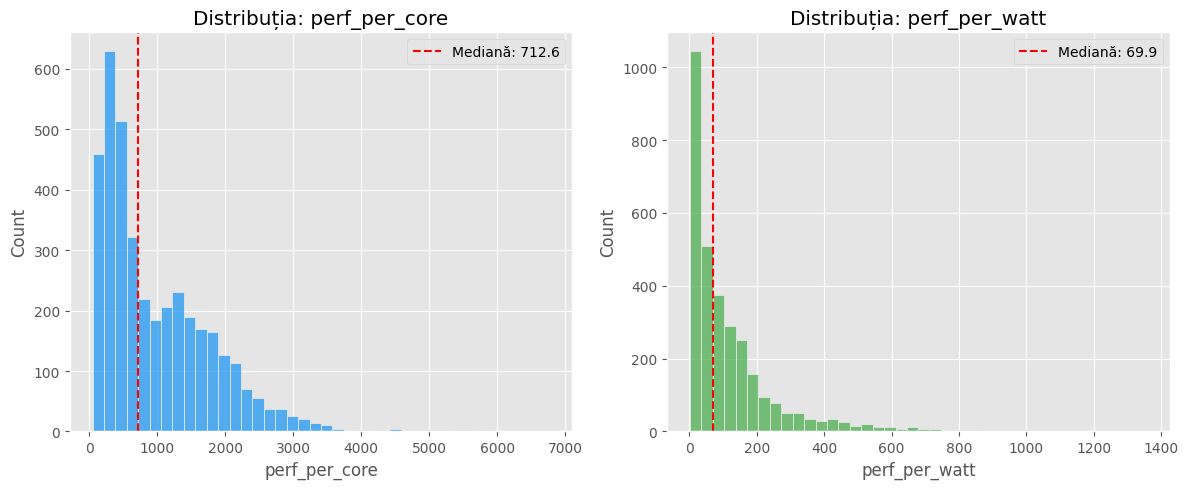

In [298]:
new_features = ['perf_per_core', 'perf_per_watt']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, feat in enumerate(new_features):
    data = df_fe[feat].dropna()
    sns.histplot(data, bins=40, ax=axes[i], color=['#2196F3', '#4CAF50', '#FF9800'][i])
    axes[i].set_title(f'Distribuția: {feat}')
    axes[i].set_xlabel(feat) 
    median_val = data.median()
    axes[i].axvline(median_val, color='red', linestyle='--', label=f'Mediană: {median_val:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 2. Calcularea și analiza corelațiilor
### 2.1 Corelația Pearson
Corelația Pearson măsoară relația **liniară** între două variabile. Valorile apropiate de ±1 indică o corelație puternică, iar cele apropiate de 0 indică lipsa unei corelații liniare.

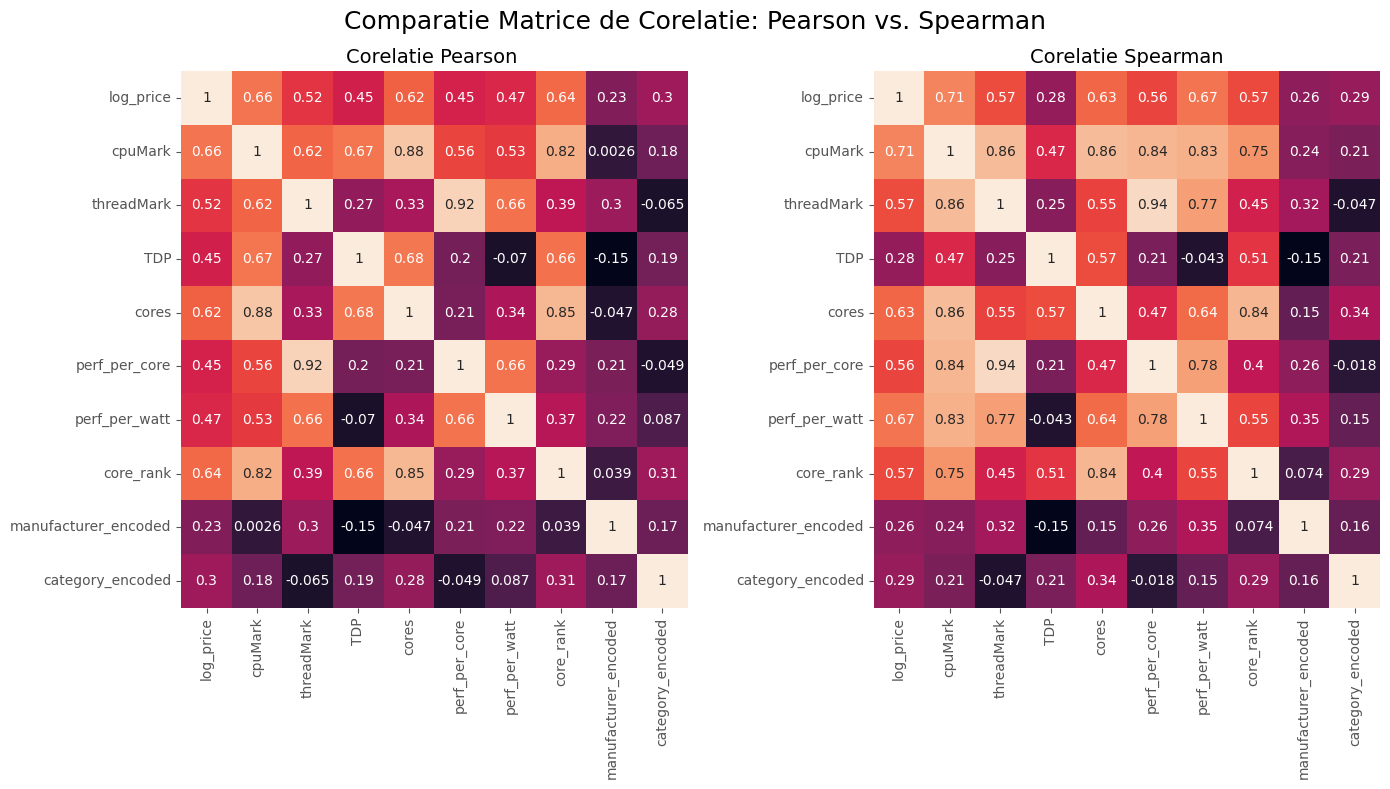

,Pearson,Spearman,Diff
perf_per_watt,0.474719,0.665291,0.190573
TDP,0.445253,0.280986,0.164267
perf_per_core,0.454667,0.556155,0.101488
core_rank,0.637955,0.565305,0.072650
threadMark,0.515475,0.574595,0.059120
cpuMark,0.664560,0.707699,0.043139
manufacturer_encoded,0.229643,0.262463,0.032820
category_encoded,0.302246,0.285027,0.017219
cores,0.617696,0.629178,0.011482


In [299]:
df_numeric = df_fe.dropna()

corr_pearson = df_numeric.corr(method='pearson', numeric_only=True)
corr_spearson = df_numeric.corr(method='spearman', numeric_only=True)


fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.heatmap(corr_pearson, annot=True, ax=axes[0], cbar=False)
axes[0].set_title('Corelatie Pearson ', fontsize=14)

sns.heatmap(corr_spearson, annot=True, ax=axes[1], cbar=False)
axes[1].set_title('Corelatie Spearman', fontsize=14)

fig.suptitle('Comparatie Matrice de Corelatie: Pearson vs. Spearman', fontsize=18)

plt.tight_layout()
plt.show()


comparison = pd.DataFrame({
    'Pearson': corr_pearson['log_price'].drop('log_price'),
    'Spearman': corr_spearson['log_price'].drop('log_price'),
    'Diff': abs(corr_pearson['log_price'].drop('log_price') - corr_spearson['log_price'].drop('log_price'))
}).sort_values('Diff', ascending=False)

display(comparison)

### 2.3 Vizualizarea relațiilor cu variabila țintă
Scatter plot-urile ajută la identificarea **tipului de relație** (liniară, exponențială, etc.) între fiecare caracteristică și prețul logaritmic.

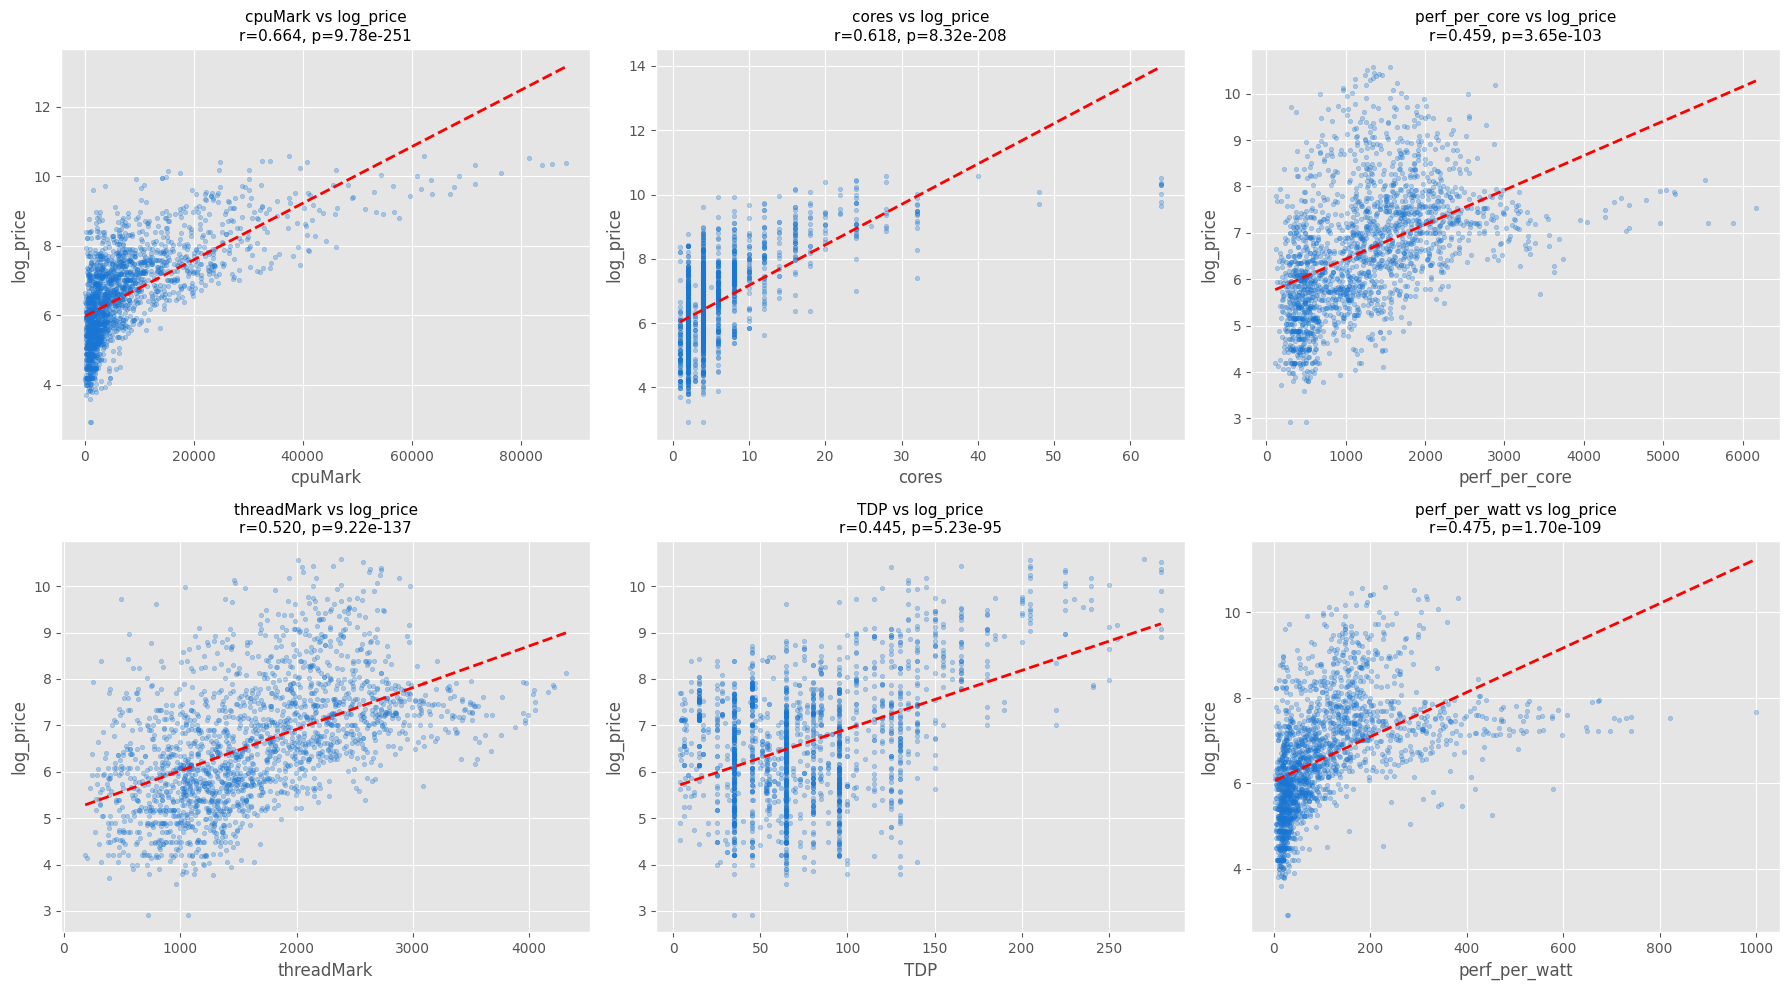

In [300]:
# Scatter plots pentru cele mai importante caracteristici
top_features = ['cpuMark', 'cores', 'perf_per_core', 'threadMark', 'TDP', 'perf_per_watt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data = df_fe[[feat, 'log_price']].dropna()
    axes[i].scatter(data[feat], data['log_price'], alpha=0.3, s=10, color='#1976D2')
    
    # Linia de regresie
    z = np.polyfit(data[feat], data['log_price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[feat].min(), data[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--')
    
    r, p_val = stats.pearsonr(data[feat], data['log_price'])
    axes[i].set_title(f'{feat} vs log_price\nr={r:.3f}, p={p_val:.2e}', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('log_price')

plt.tight_layout()
plt.show()

## 3. Importanța caracteristicilor
### 3.1 Random Forest Feature Importance
Folosim un model Random Forest pentru a estima importanța fiecărei caracteristici în predicția prețului. Importanța se bazează pe cât de mult contribuie fiecare caracteristică la reducerea impurității (Mean Decrease in Impurity).

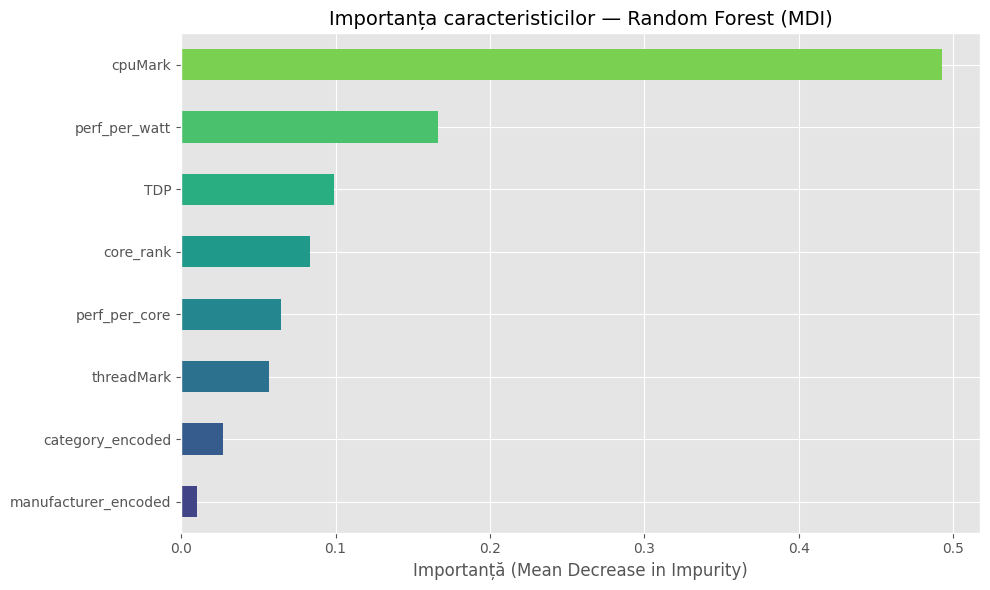


Scorul R² pe setul de test: 0.6588
Scorul R² pe setul de antrenament: 0.8287


In [301]:
feature_cols = ['cpuMark', 'threadMark', 'TDP',
                'perf_per_core', 'perf_per_watt',
                'core_rank', 'manufacturer_encoded', 'category_encoded']

df_model = df_fe.dropna()
X = df_model[feature_cols]
y = df_model['log_price']

# Împărțirea în train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33550336)


rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,             
    min_samples_split=10,     
    min_samples_leaf=4,       
    random_state=33550336, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Importanța caracteristicilor (MDI)
importances_mdi = pd.Series(rf.feature_importances_, index=feature_cols)
importances_mdi = importances_mdi.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importances_mdi)))
importances_mdi.plot(kind='barh', color=colors)
plt.title('Importanța caracteristicilor — Random Forest (MDI)', fontsize=14)
plt.xlabel('Importanță (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

print(f'\nScorul R² pe setul de test: {rf.score(X_test, y_test):.4f}')
print(f'Scorul R² pe setul de antrenament: {rf.score(X_train, y_train):.4f}')